# Computer Systems Concepts: Data, Memory, Compilation, and the Stack

**Domain:** `systems`
**Level:** Beginner-friendly intro, intermediate/advanced rigor
**Prerequisites:** basic programming (any language), comfort with a terminal;
no prior computer-architecture or compilers background needed
**Languages:** Python/NumPy for measurement and visualization; real, compiled
C (via `gcc`, MSYS2/MinGW-w64 on this machine) for everything that has to
happen below the level Python normally shows you -- see `src/`

Every program you've ever written -- Python, JavaScript, whatever --
eventually turns into something much less friendly: a sequence of bytes
sitting in memory, and a processor blindly executing them one instruction
at a time. Python hides that machine from you on purpose. This tutorial
takes the hood off.

We'll answer four concrete questions, each with **real measurements from
this machine**, not just diagrams:

1. **Data representation** -- when you write `x = -1` or `y = 0.1`, what
   bits actually get stored, and why does `0.1 + 0.2 != 0.3`?
2. **The memory hierarchy** -- why is reading memory in one order 5x
   slower than another order, even though it's the *same data*?
3. **The compilation pipeline** -- what actually happens between typing
   `gcc program.c` and having a runnable `.exe`?
4. **The stack & calling conventions** -- when function `f` calls function
   `g`, where do `g`'s arguments and local variables physically live, and
   how does execution find its way back to `f` afterward?

By the end you'll be able to explain (and reproduce) all four using
nothing but a terminal, `gcc`, and NumPy -- the same tools real systems
programmers reach for.

> This tutorial is deliberately **machine-facing**: two's complement,
> IEEE-754, cache lines, object files, stack frames. A companion tutorial
> on **OS-level abstractions** (processes, virtual memory, scheduling,
> syscalls) covers the layer *above* this one -- the operating system's
> view rather than the raw hardware's view.

## Part I -- Data representation

### The idea, intuitively

Computers only store **bits**: 0s and 1s. Everything -- integers, text,
floats, images -- is some agreed-upon *encoding* of bits into meaning.
Two encodings cause the vast majority of real-world numerical bugs, so
we'll focus on those: **two's complement** integers and **IEEE-754**
floating point.

**Two's complement, the odometer analogy.** Picture a car odometer with a
fixed number of digits. If it reads `00000` and you drive backwards, it
doesn't go negative -- it wraps around to `99999`. Computer integers work
the same way, just in binary and with a fixed number of *bits* instead of
decimal digits. An 8-bit unsigned counter that overflows past 255 wraps to
0. **Two's complement** is the clever trick that lets the *same* wraparound
hardware also represent negative numbers: instead of splitting a separate
sign bit off, the top half of the bit patterns (arithmetically, the ones
where the leading bit is 1) is simply *reinterpreted* as negative numbers.
Let's see the wraparound before proving anything about it:

In [1]:
import numpy as np

# An 8-bit signed integer can represent -128 .. 127. Watch what happens
# one step past the top of that range.
x = np.int8(127)
print("127 + 1 as int8 =", np.int8(x + np.int8(1)))

127 + 1 as int8 = -128


C:\Users\thoma\AppData\Local\Temp\ipykernel_23500\3398040593.py:6: RuntimeWarning: overflow encountered in scalar add
  print("127 + 1 as int8 =", np.int8(x + np.int8(1)))


`127 + 1` "should" be 128 -- but an `int8` only has 256 possible bit
patterns, and 128 isn't one of the values it can represent, so it silently
**wraps around to -128**, the most negative representable value. This is
exactly the odometer rolling over. NumPy makes this visible because it
gives you fixed-width integer types the way C does; plain Python `int`
never overflows because it grows arbitrarily large -- which is convenient,
but also means plain Python hides a class of bugs that shows up constantly
in C, Java, Rust (in release mode), and hardware.

**IEEE-754 floats, the ruler analogy.** Imagine a ruler where the tick
marks get *farther apart* the further you are from zero -- lots of
precision near zero, coarser precision for huge numbers, but always the
same *number* of tick marks (bits) to work with. That's a floating-point
number: a sign, an *exponent* (how far out on the ruler you are, i.e. the
overall scale), and a *mantissa* (where between the surrounding tick marks
you land). Because only finitely many bits are available, most decimal
fractions -- including something as ordinary as 0.1 -- **cannot be stored
exactly**, for the same reason 1/3 cannot be written exactly in a finite
number of decimal digits.

In [2]:
print("0.1 + 0.2         =", 0.1 + 0.2)
print("0.1 + 0.2 == 0.3 ?", 0.1 + 0.2 == 0.3)
print("0.1 + 0.2 - 0.3   =", 0.1 + 0.2 - 0.3)

0.1 + 0.2         = 0.30000000000000004
0.1 + 0.2 == 0.3 ? False
0.1 + 0.2 - 0.3   = 5.551115123125783e-17


That tiny leftover (`5.55e-17`) isn't a bug in Python, or in your CPU --
it's the ruler-tick-mark problem above, made visible. Both 0.1 and 0.2 get
rounded to the *nearest representable* float before any arithmetic even
happens, and the rounding errors don't cancel. We'll pin down exactly why,
bit for bit, in the next section.

**Takeaway:** every number you use in a program is secretly an encoding
with sharp edges -- integers wrap at fixed boundaries, and most floats are
already approximations before you've done a single calculation with them.

### Going deeper: the formal definitions

#### Two's complement, precisely

For an $n$-bit two's complement integer with bits $b_{n-1} b_{n-2} \dots
b_1 b_0$ (from most to least significant), the represented value is
defined as:

$$
v = -b_{n-1} \cdot 2^{n-1} \;+\; \sum_{i=0}^{n-2} b_i \cdot 2^{i}
$$

That is: every bit contributes its usual positive place value, **except**
the top bit, which contributes a *negative* place value. This single sign
flip on the most significant bit is the entire trick.

**Range.** The most negative value is `1000...0` ($b_{n-1}=1$, all others
0): $v = -2^{n-1}$. The most positive value is `0111...1`: $v =
2^{n-1} - 1$. So an $n$-bit two's complement integer represents exactly
the range $[-2^{n-1},\, 2^{n-1}-1]$ -- asymmetric by exactly one, because
zero uses up one of the $2^n$ available bit patterns on the non-negative
side.

**Why it wraps (the modular arithmetic view).** Two's complement is
equivalent to ordinary unsigned addition modulo $2^n$, followed by
reinterpreting the top half of the result range as negative. Concretely,
for a value $v$ with $-2^{n-1} \le v < 0$, its bit pattern equals the bit
pattern of $v + 2^n$ interpreted as unsigned -- so signed and unsigned
addition use **the exact same hardware adder circuit**; only the
*interpretation* of the bits differs. This is why the `int8` overflow
above produced $-128$: $127 + 1 = 128$, and $128 \bmod 256 = 128$, which
as an 8-bit two's complement pattern (`10000000`) is $-2^7 = -128$.

**Signed vs. unsigned overflow.** Unsigned overflow (wrapping mod $2^n$)
is well-defined behavior in C. Signed integer overflow, by contrast, is
formally **undefined behavior** in C/C++ -- compilers are legally allowed
to assume it never happens, and may optimize code in ways that look wrong
if it does. We'll return to why that's controversial in "Limitations &
debates."

#### IEEE-754, precisely

A 64-bit ("double precision") IEEE-754 float packs three fields into 64
bits: a 1-bit sign $s$, an 11-bit biased exponent $e$, and a 52-bit
mantissa (significand) $m$. For a normal (non-zero, non-subnormal) value,
the represented value is:

$$
v = (-1)^{s} \times 1.m \times 2^{\,e - 1023}
$$

where $1.m$ means "1, followed by the 52 mantissa bits interpreted as
binary fractional digits" (the leading 1 is *implicit* -- it's never
stored, because every normal float's mantissa can always be normalized to
start with a 1, so storing it would waste a bit). The **1023 bias** lets
the 11-bit exponent field, which only stores non-negative integers
$0$--$2047$, represent true exponents from $-1022$ to $+1023$.

Let's decompose a real float's bits by hand and check the formula against
Python's own float parsing.

In [3]:
import struct

def decompose_ieee754_double(x: float) -> dict:
    '''Break a Python float into its raw IEEE-754 sign/exponent/mantissa
    fields and reconstruct the value from the formula above, so we can
    verify the formula against the float we started with.'''
    raw = struct.unpack(">Q", struct.pack(">d", x))[0]   # 64 raw bits, as an unsigned int
    sign_bit = (raw >> 63) & 0x1
    exp_bits = (raw >> 52) & 0x7FF          # 11 bits
    mantissa_bits = raw & ((1 << 52) - 1)   # 52 bits

    sign = -1.0 if sign_bit else 1.0
    exponent = exp_bits - 1023              # undo the bias
    mantissa = 1 + mantissa_bits / (2 ** 52)  # implicit leading 1
    reconstructed = sign * mantissa * (2.0 ** exponent)

    return {
        "sign_bit": sign_bit,
        "exponent_bits": format(exp_bits, "011b"),
        "exponent_unbiased": exponent,
        "mantissa_bits": format(mantissa_bits, "052b"),
        "1.mantissa (decimal)": mantissa,
        "reconstructed_value": reconstructed,
        "matches_original": reconstructed == x,
    }

for val in (0.1, 0.2, 0.3, -3.5, 1.0):
    info = decompose_ieee754_double(val)
    print(f"x = {val}")
    for k, v in info.items():
        print(f"    {k:22s} = {v}")
    print()

x = 0.1
    sign_bit               = 0
    exponent_bits          = 01111111011
    exponent_unbiased      = -4
    mantissa_bits          = 1001100110011001100110011001100110011001100110011010
    1.mantissa (decimal)   = 1.6
    reconstructed_value    = 0.1
    matches_original       = True

x = 0.2
    sign_bit               = 0
    exponent_bits          = 01111111100
    exponent_unbiased      = -3
    mantissa_bits          = 1001100110011001100110011001100110011001100110011010
    1.mantissa (decimal)   = 1.6
    reconstructed_value    = 0.2
    matches_original       = True

x = 0.3
    sign_bit               = 0
    exponent_bits          = 01111111101
    exponent_unbiased      = -2
    mantissa_bits          = 0011001100110011001100110011001100110011001100110011
    1.mantissa (decimal)   = 1.2
    reconstructed_value    = 0.3
    matches_original       = True

x = -3.5
    sign_bit               = 1
    exponent_bits          = 10000000000
    exponent_unbiased      = 1
   

Now the `0.1 + 0.2 != 0.3` mystery has a precise, bit-level answer: the
52-bit mantissa of 0.1 and of 0.2 are each already **rounded** to the
nearest representable double (their true binary expansions are infinite
repeating fractions, just like 1/3 in decimal), and adding two
already-rounded numbers accumulates a rounding error that doesn't happen
to cancel out to exactly 0.3's own rounded representation. Inspect the
mantissa bits printed above for 0.1 and 0.3 -- neither is a "clean" binary
fraction, exactly analogous to how 1/3 = 0.333... never terminates in
decimal.

**Machine epsilon.** The largest relative rounding error introduced by
representing one real number as the nearest double is bounded by machine
epsilon, $\varepsilon = 2^{-52} \approx 2.22\times10^{-16}$ for float64 --
this is `np.finfo(np.float64).eps` and is *the* number that governs "how
many digits of a `float64` can I trust," roughly 15-16 significant
decimal digits.

### Visuals: overflow wraparound and shrinking float precision

First, the two's complement "odometer" made visual: sweep an 8-bit signed
value across its entire range and watch it wrap.

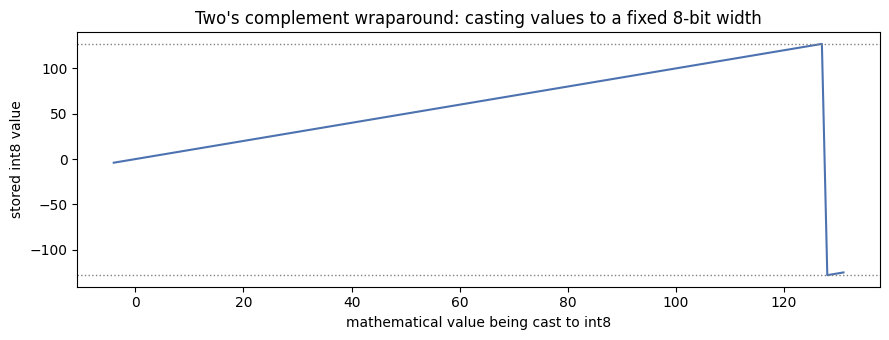

In [4]:
import matplotlib.pyplot as plt
import numpy as np

xs = np.arange(-4, 132)  # sweep past both ends of int8's range on purpose
wrapped = xs.astype(np.int8)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(xs, wrapped, color="#4C72B0", lw=1.5)
ax.axhline(127, color="gray", ls=":", lw=1)
ax.axhline(-128, color="gray", ls=":", lw=1)
ax.set_xlabel("mathematical value being cast to int8")
ax.set_ylabel("stored int8 value")
ax.set_title("Two's complement wraparound: casting values to a fixed 8-bit width")
plt.tight_layout()
plt.savefig("overflow_wraparound.png", dpi=110)
plt.show()

Second, the "ruler with uneven tick marks" made visual: the *gap* between
one representable `float64` and the next, as a function of magnitude.

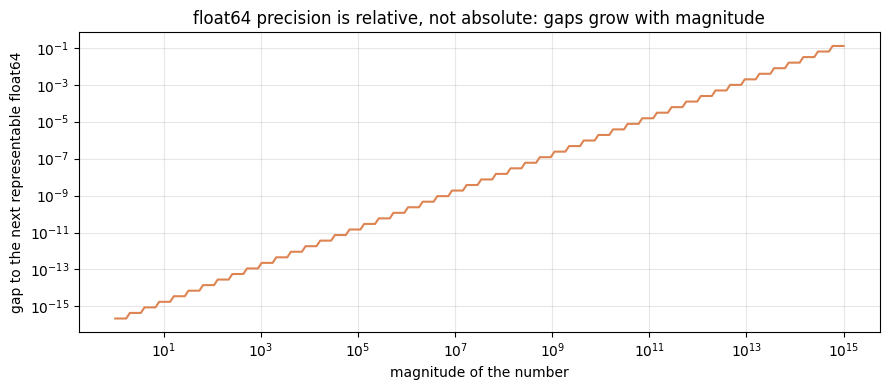

gap near 1.0:       2.220e-16
gap near 1e10:      1.907e-06
gap near 1e15:      1.250e-01


In [5]:
magnitudes = np.logspace(0, 15, 200)
gaps = np.nextafter(magnitudes, np.inf) - magnitudes

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(magnitudes, gaps, color="#DD8452")
ax.set_xlabel("magnitude of the number")
ax.set_ylabel("gap to the next representable float64")
ax.set_title("float64 precision is relative, not absolute: gaps grow with magnitude")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("float_precision_gaps.png", dpi=110)
plt.show()

print(f"gap near 1.0:       {np.nextafter(1.0, np.inf) - 1.0:.3e}")
print(f"gap near 1e10:      {np.nextafter(1e10, np.inf) - 1e10:.3e}")
print(f"gap near 1e15:      {np.nextafter(1e15, np.inf) - 1e15:.3e}")

Both plots are the same idea from two angles: a fixed number of bits
means a fixed number of distinguishable values, so as the *range* you're
trying to cover grows (bigger magnitude floats, or wraparound past an
integer's max), the *precision* per representable value has to shrink or
wrap. Near 1.0 a `float64`'s neighboring values are about $2\times
10^{-16}$ apart; near $10^{15}$ they're already a whole integer apart --
which is exactly why adding 1 to a sufficiently large float silently does
nothing.

### Implementation: overflow across integer widths, and a from-scratch float decoder

We already wrote `decompose_ieee754_double` above; let's stress-test both
ideas across more cases, including confirming that overflow behavior
scales with bit width exactly as the formula predicts.

In [6]:
# Overflow at every common fixed integer width, at exactly the boundary.
for dtype in (np.int8, np.int16, np.int32, np.int64):
    info = np.iinfo(dtype)
    max_plus_one = dtype(info.max) + dtype(1)  # NumPy overflow wraps, doesn't raise
    print(f"{dtype.__name__:6s}: range=[{info.min:>20,}, {info.max:>20,}]  "
          f"max+1 wraps to {max_plus_one}")

int8  : range=[                -128,                  127]  max+1 wraps to -128
int16 : range=[             -32,768,               32,767]  max+1 wraps to -32768
int32 : range=[      -2,147,483,648,        2,147,483,647]  max+1 wraps to -2147483648
int64 : range=[-9,223,372,036,854,775,808, 9,223,372,036,854,775,807]  max+1 wraps to -9223372036854775808


C:\Users\thoma\AppData\Local\Temp\ipykernel_23500\339969186.py:4: RuntimeWarning: overflow encountered in scalar add
  max_plus_one = dtype(info.max) + dtype(1)  # NumPy overflow wraps, doesn't raise


Every width wraps to its own minimum, exactly as
$v = -2^{n-1} + \sum b_i 2^i$ predicts: the bit pattern for "max + 1" is
always `1000...0`, i.e. exactly $-2^{n-1}$, regardless of $n$.

In [7]:
# Special IEEE-754 values: decompose_ieee754_double handles the *normal*
# case; infinities/NaN use reserved all-1s exponent fields as a special case.
special_raw = {
    "+inf": struct.pack(">d", float("inf")).hex(),
    "-inf": struct.pack(">d", float("-inf")).hex(),
    "nan":  struct.pack(">d", float("nan")).hex(),
    "-0.0": struct.pack(">d", -0.0).hex(),
}
for name, hexbits in special_raw.items():
    print(f"{name:5s} -> raw bytes 0x{hexbits}")

print()
print("all-1s exponent field (0x7FF) is reserved for +-inf and NaN;")
print("this is why the *normal* formula above assumes exponent bits are")
print("not all 0 (subnormals) or all 1 (inf/NaN).")

+inf  -> raw bytes 0x7ff0000000000000
-inf  -> raw bytes 0xfff0000000000000
nan   -> raw bytes 0x7ff8000000000000
-0.0  -> raw bytes 0x8000000000000000

all-1s exponent field (0x7FF) is reserved for +-inf and NaN;
this is why the *normal* formula above assumes exponent bits are
not all 0 (subnormals) or all 1 (inf/NaN).


## Part II -- The memory hierarchy & caching

### The idea, intuitively

Imagine a library. If you're actively working, you keep a few books open
on your desk -- instant to grab. The shelf across the room takes a short
walk. The archive in the basement takes a trip down the stairs. And a
book that's out on inter-library loan from another campus could take
days. **Every level is bigger but slower than the one before it** -- that
trade-off is the memory hierarchy.

Your computer is built the same way, just with dramatically more extreme
ratios: tiny **registers** inside the CPU (a handful of values, ~0 delay),
a small **cache** a few steps away (megabytes, extremely fast), **RAM**
(gigabytes, noticeably slower), and **disk** (terabytes, orders of
magnitude slower still). A program that keeps reusing data that's already
"on the desk" runs dramatically faster than one that keeps walking to the
basement -- **even when both do the exact same amount of arithmetic**.
Let's see that happen, not just assert it:

In [8]:
import time
import numpy as np

n = 4000
a = np.random.rand(n, n)  # a big 2D array of the SAME data either way

def sum_row_major(a):
    '''Walk memory the way it's laid out: row by row.'''
    total = 0.0
    for i in range(a.shape[0]):
        total += a[i, :].sum()
    return total

def sum_col_major(a):
    '''Walk the SAME data column by column instead.'''
    total = 0.0
    for j in range(a.shape[1]):
        total += a[:, j].sum()
    return total

sum_row_major(a); sum_col_major(a)  # warm up (page faults, etc.)

t0 = time.perf_counter(); sum_row_major(a); t1 = time.perf_counter()
t2 = time.perf_counter(); sum_col_major(a); t3 = time.perf_counter()

row_time, col_time = t1 - t0, t3 - t2
print(f"row-major traversal: {row_time*1000:.1f} ms")
print(f"col-major traversal: {col_time*1000:.1f} ms")
print(f"col-major is {col_time / row_time:.2f}x slower -- same data, same total work, different order")

row-major traversal: 60.6 ms
col-major traversal: 298.4 ms
col-major is 4.93x slower -- same data, same total work, different order


**Same array, same total arithmetic, same number of additions -- and one
order is measurably slower than the other, on this exact machine, just
now.** The only difference is the *order* memory got touched in. That's
not a fluke; it's the entire memory hierarchy made visible in one
benchmark, and the next section explains precisely why.

**Takeaway:** how you access memory can matter as much as what you
compute -- an algorithm with worse Big-O complexity but cache-friendly
access patterns regularly beats a "better" algorithm with poor locality.

### Going deeper: cache lines, locality, and the latency ladder

**Why NumPy arrays are laid out the way they are.** A 2D NumPy array is,
underneath, one long flat run of bytes in memory (**row-major / "C"
order** by default: row 0's elements, then row 1's elements, ...). So
`a[i, :]` (one row) is a *contiguous* run of bytes, while `a[:, j]` (one
column) is scattered across memory with a big stride between elements.

**Cache lines.** The CPU never fetches a single byte or a single float
from RAM in isolation -- it fetches a whole **cache line** at a time,
typically **64 bytes** on modern x86-64 hardware. A `float64` is 8 bytes,
so one 64-byte cache line holds exactly **8 consecutive `float64`
values**. This is the crux of the whole benchmark above:

- **Row-major traversal**: reading `a[i,0], a[i,1], ..., a[i,7]` pulls in
  *one* cache line and then uses every byte of it before moving on. 1
  cache-line fetch serves 8 useful reads.
  This exploits **spatial locality**: nearby memory addresses tend to be
  accessed together.
- **Column-major traversal**: reading `a[0,j], a[1,j], a[2,j], ...` jumps
  `n` elements ($n\times 8$ bytes) between each read. Each read lands on
  a *different* cache line, most of which get evicted before their other
  7 values are ever used. Roughly 1 cache-line fetch per **1** useful
  read -- 8x more memory traffic for the identical data.

**Temporal locality** is the sibling idea: if you access address $X$ now,
you're likely to access $X$ again soon (e.g. a loop counter, or values
reused across nearby iterations) -- caches also exploit this by simply
*keeping recently-used lines around*.

**The latency ladder.** Here are commonly cited approximate latencies
(order-of-magnitude figures popularized as "Latency Numbers Every
Programmer Should Know," originally attributed to Jeff Dean, with the
interactive visualization by Colin Scott cited in References). Exact
numbers vary by hardware generation, but the *ratios* between rungs are
the lesson:

| Operation | Approx. latency | Relative to L1 cache |
|---|---|---|
| L1 cache reference | ~1 ns | 1x |
| L2 cache reference | ~4 ns | ~4x |
| Main memory (RAM) reference | ~100 ns | ~100x |
| SSD random read | ~10-150 us | ~10,000-150,000x |
| Rotational disk seek | ~1-10 ms | ~1,000,000x+ |
| Network round trip, same datacenter | ~0.5 ms | ~500,000x |
| Network round trip, cross-continent | ~100-150 ms | ~100,000,000x+ |

The gap between "L1 cache" and "main memory" alone is roughly the same
*ratio* as the gap between a human heartbeat and a full day -- which is
why cache-conscious code (or, further down the ladder, minimizing disk
seeks and network round trips) is often the single biggest lever on real
program performance, bigger than most micro-optimizations.

### Visuals & implementation: the latency ladder, and a stride benchmark

First, the latency table above, plotted on a log scale so the *order-of-
magnitude* jumps between rungs are visible at a glance.

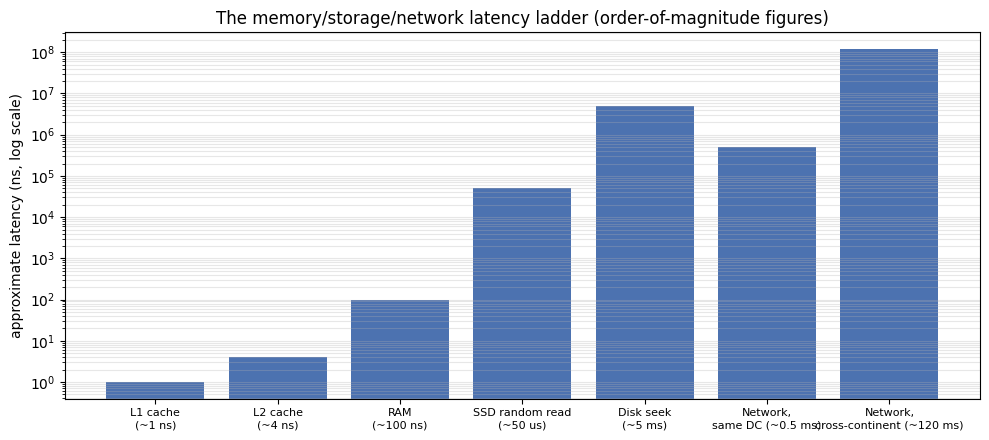

In [9]:
labels = ["L1 cache\n(~1 ns)", "L2 cache\n(~4 ns)", "RAM\n(~100 ns)",
          "SSD random read\n(~50 us)", "Disk seek\n(~5 ms)",
          "Network,\nsame DC (~0.5 ms)", "Network,\ncross-continent (~120 ms)"]
latencies_ns = [1, 4, 100, 50_000, 5_000_000, 500_000, 120_000_000]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(range(len(labels)), latencies_ns, color="#4C72B0")
ax.set_yscale("log")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("approximate latency (ns, log scale)")
ax.set_title("The memory/storage/network latency ladder (order-of-magnitude figures)")
ax.grid(alpha=0.3, axis="y", which="both")
plt.tight_layout()
plt.savefig("latency_ladder.png", dpi=110)
plt.show()

Next, a cleaner, more controlled version of the row/column benchmark:
instead of comparing two access *patterns*, directly vary the **stride**
(the gap, in array elements, between consecutive reads) while holding the
*number* of reads fixed, so the only thing changing between runs is
spatial locality itself.

In [10]:
n_elements = 8_000_000   # ~64 MB of float64 -- comfortably bigger than any cache
big_array = np.random.rand(n_elements)
n_accesses = 2_000_000   # SAME number of reads every time

strides = [1, 2, 4, 8, 16, 32, 64, 128]
stride_times_ms = []

for stride in strides:
    idx = (np.arange(n_accesses) * stride) % n_elements
    big_array[idx].sum()  # warm up
    t0 = time.perf_counter()
    for _ in range(3):
        big_array[idx].sum()
    t1 = time.perf_counter()
    stride_times_ms.append((t1 - t0) / 3 * 1000)
    print(f"stride={stride:4d} elements ({stride*8:5d} bytes)  "
          f"time={stride_times_ms[-1]:6.2f} ms")

stride=   1 elements (    8 bytes)  time= 15.48 ms
stride=   2 elements (   16 bytes)  time= 18.05 ms


stride=   4 elements (   32 bytes)  time= 22.32 ms
stride=   8 elements (   64 bytes)  time= 32.16 ms


stride=  16 elements (  128 bytes)  time= 38.16 ms
stride=  32 elements (  256 bytes)  time= 35.45 ms


stride=  64 elements (  512 bytes)  time= 40.39 ms


stride= 128 elements ( 1024 bytes)  time= 47.18 ms


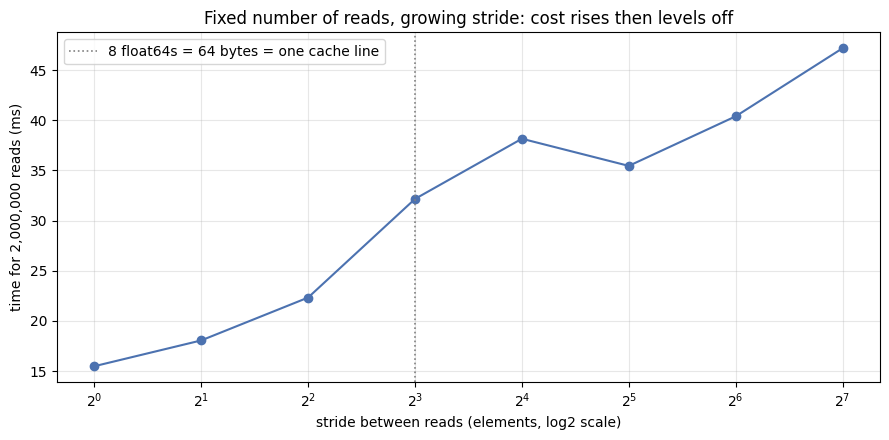

stride=128 is 3.05x slower than stride=1, for the SAME number of reads


In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(strides, stride_times_ms, "o-", color="#4C72B0")
ax.axvline(8, color="gray", ls=":", lw=1.2,
           label="8 float64s = 64 bytes = one cache line")
ax.set_xscale("log", base=2)
ax.set_xlabel("stride between reads (elements, log2 scale)")
ax.set_ylabel(f"time for {n_accesses:,} reads (ms)")
ax.set_title("Fixed number of reads, growing stride: cost rises then levels off")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("stride_benchmark.png", dpi=110)
plt.show()

slowdown = stride_times_ms[-1] / stride_times_ms[0]
print(f"stride={strides[-1]} is {slowdown:.2f}x slower than stride=1, for the SAME number of reads")

Interpreting the actual numbers from this run: cost climbs steadily as
the stride grows from 1 toward 8 elements (64 bytes -- one cache line),
because up to that point every stride increase means *fewer* of the 8
values in each fetched cache line get reused before the line is evicted.
Past a stride of 8 elements, every single read already lands on a *fresh*
cache line regardless of how much further apart it is spread, so the
curve **levels off rather than continuing to climb linearly** -- exactly
the signature you'd expect if 64 bytes really is the hardware's unit of
transfer. (Real hardware also has multiple cache *levels* and a
memory-page component from the TLB, which is part of why the curve isn't
perfectly flat past 8 either -- see "Limitations & debates.")

## Part III -- The compilation pipeline

### The idea, intuitively

Turning `gcc program.c -o program.exe` into a runnable binary isn't one
step -- it's a **pipeline of four distinct translators**, each handing
its output to the next, like a manuscript passing through four different
editors before it's a printed, bound book:

1. **Preprocessing** -- a find-and-replace editor. It expands `#include`
   files and `#define` macros textually, before anyone has thought about
   what the code *means*.
2. **Compilation** -- translates the (now macro-free) C source into
   assembly language, a human-readable form of the CPU's actual
   instruction set.
3. **Assembly** -- turns that human-readable assembly into an **object
   file**: real machine code bytes, but not yet a runnable program (it's
   missing pieces that live in other files).
4. **Linking** -- glues multiple object files and libraries together,
   resolving cross-references (e.g. your `main` calling `printf`, which
   lives in the C standard library, not your file) into one final
   executable.

We'll run all four stages for real, on a tiny C program, and look at the
actual intermediate output at each step -- not a diagram standing in for
it.

In [12]:
print(open("src/pipeline_demo.c").read())

/* pipeline_demo.c
 *
 * A tiny C program used to walk through the compilation pipeline:
 * preprocessing (-E), compilation to assembly (-S), assembling to an
 * object file (-c), and linking to a final executable.
 */
#include <stdio.h>

/* A macro: the preprocessor will textually substitute SQUARE(x) with
 * ((x) * (x)) wherever it is used, before the compiler proper ever runs. */
#define SQUARE(x) ((x) * (x))

int add(int a, int b) {
    return a + b;
}

int main(void) {
    int x = 5;
    int y = SQUARE(x);      /* becomes ((x) * (x)) after preprocessing */
    int z = add(x, y);
    printf("x=%d y=%d z=%d\n", x, y, z);
    return 0;
}



Note the `#define SQUARE(x) ((x) * (x))` macro and the `add` function --
we'll watch the macro disappear (textually inlined) after preprocessing,
and watch `add` turn into real assembly instructions after compilation.

### Going deeper: what each stage actually produces

- **Object files** (`.o` here; `.obj` is the equivalent on some
  toolchains) contain machine code **plus a symbol table**: a list of
  names (like `add` or `printf`) the file defines, and names it *needs*
  but doesn't define -- these are called **unresolved external
  references**. A single object file is not runnable by itself.
- **Linking** walks every object file and every needed library, matches
  up "needs `printf`" with "the C runtime library defines `printf`," and
  patches in the real memory addresses (a step called **relocation**),
  producing one self-contained (in the static-linking case) executable.
- **Static vs. dynamic linking.** Static linking (what we use here, via
  `-static`) copies the needed library code directly into the final
  executable at link time -- bigger file, but no dependency on
  matching `.dll`/`.so` files being present at run time. Dynamic linking
  instead leaves a reference to a shared library that's resolved when the
  program *starts* (or even later, on first use) -- smaller executables
  that share one copy of the library in memory across many running
  programs, at the cost of needing that library installed and
  version-compatible on whatever machine runs it.
- **Loading.** Even after linking, one more step happens at run time: the
  OS's *loader* maps the executable's code and data into a fresh
  process's virtual address space and transfers control to its entry
  point. (Loading and virtual memory belong to the OS-abstractions layer;
  the compilation pipeline's job ends at producing the executable file.)

Let's run the real pipeline.

In [13]:
import subprocess, pathlib

GCC = r"C:\msys64\ucrt64\bin\gcc.exe"
src_dir = pathlib.Path("src")
c_file = src_dir / "pipeline_demo.c"

# Stage 1: preprocessing only (-E). No compilation happens yet.
result = subprocess.run([GCC, "-E", str(c_file)], capture_output=True, text=True)
assert result.returncode == 0, result.stderr
preprocessed = result.stdout
print("--- last 12 lines of preprocessed output ---")
print("\n".join(preprocessed.splitlines()[-12:]))

--- last 12 lines of preprocessed output ---
# 13 "src\\pipeline_demo.c"
int add(int a, int b) {
    return a + b;
}

int main(void) {
    int x = 5;
    int y = ((x) * (x));
    int z = add(x, y);
    printf("x=%d y=%d z=%d\n", x, y, z);
    return 0;
}


`#include <stdio.h>` has been replaced by hundreds of lines of standard
library declarations (trimmed above for space), and -- the detail to
notice -- `SQUARE(x)` is gone entirely, textually replaced by
`((x) * (x))`. The preprocessor doesn't know or care what a `long long`
or an `int` even is; it's pure text substitution.

In [14]:
# Stage 2: compile preprocessed source down to assembly (-S), not machine code yet.
result = subprocess.run(
    [GCC, "-S", "-O0", "-std=c17", str(c_file), "-o", str(src_dir / "pipeline_demo.s")],
    capture_output=True, text=True,
)
assert result.returncode == 0, result.stderr

asm_text = (src_dir / "pipeline_demo.s").read_text()
# Pull out just the add() function's assembly for a focused look.
lines = asm_text.splitlines()
start = next(i for i, l in enumerate(lines) if l.strip() == "add:")
end = next(i for i, l in enumerate(lines[start:], start) if "ret" in l) + 1
print("\n".join(lines[start:end]))

add:
	pushq	%rbp
	.seh_pushreg	%rbp
	movq	%rsp, %rbp
	.seh_setframe	%rbp, 0
	.seh_endprologue
	movl	%ecx, 16(%rbp)
	movl	%edx, 24(%rbp)
	movl	16(%rbp), %edx
	movl	24(%rbp), %eax
	addl	%edx, %eax
	popq	%rbp
	ret


That's `int add(int a, int b) { return a + b; }` translated into real
x86-64 assembly: save the caller's base pointer, load the two arguments
from their stack slots, add them, and return. (We'll dissect exactly this
prologue/epilogue shape -- pushing `rbp`, moving `rsp` into it -- in
detail in Part IV.)

In [15]:
# Stage 3: assemble to an object file (-c) -- real machine code, not yet linked.
obj_path = src_dir / "pipeline_demo.o"
result = subprocess.run(
    [GCC, "-c", "-O0", "-std=c17", str(c_file), "-o", str(obj_path)],
    capture_output=True, text=True,
)
assert result.returncode == 0, result.stderr
print(f"object file size: {obj_path.stat().st_size} bytes")

# Inspect its symbol table with nm: defined symbols (T = text/code) vs.
# undefined ones this file still needs from elsewhere (U).
NM = r"C:\msys64\ucrt64\bin\nm.exe"
result = subprocess.run([NM, str(obj_path)], capture_output=True, text=True)
print(result.stdout)

object file size: 1014 bytes


0000000000000000 b .bss
0000000000000000 d .data
0000000000000000 p .pdata
0000000000000000 r .rdata
0000000000000000 r .rdata$zzz
0000000000000000 t .text
0000000000000000 r .xdata
                 U __main
0000000000000000 T add
0000000000000014 T main
                 U printf



`add` and `main` show up as **defined** symbols (with an address and a
`T`, meaning "defined in the code/text section"). `printf` shows up as
**undefined** (`U`) -- our object file *calls* it but doesn't *define*
it. That unresolved reference is exactly what the linker's job is to fix.

In [16]:
# Stage 4: link into a final executable. Statically linked, per this
# machine's MinGW/Windows Defender note (see the README / repo conventions).
exe_path = src_dir / "pipeline_demo.exe"
result = subprocess.run(
    [GCC, str(obj_path), "-o", str(exe_path), "-static", "-static-libgcc"],
    capture_output=True, text=True,
)
assert result.returncode == 0, result.stderr
print(f"linked executable size: {exe_path.stat().st_size:,} bytes "
      f"(vs. {obj_path.stat().st_size:,} bytes for the unlinked object file --"
      f" almost all of that growth is the statically-linked C runtime)")

run = subprocess.run([str(exe_path)], capture_output=True, text=True)
print("program output:", run.stdout.strip())

linked executable size: 131,265 bytes (vs. 1,014 bytes for the unlinked object file -- almost all of that growth is the statically-linked C runtime)


program output: x=5 y=25 z=30


And that's the full pipeline, each stage's *actual* output inspected: a
5-line C file preprocessed to library-declarations-plus-macro-expansion,
compiled to hand-readable assembly, assembled to a small object file with
one resolved and one unresolved symbol, then linked into a self-contained
executable that runs and prints `x=5 y=25 z=30` -- matching
`SQUARE(5)=25` and `add(5, 25)=30` exactly as the macro-expanded source
predicted.

### Visual: the pipeline end to end, with real artifact sizes

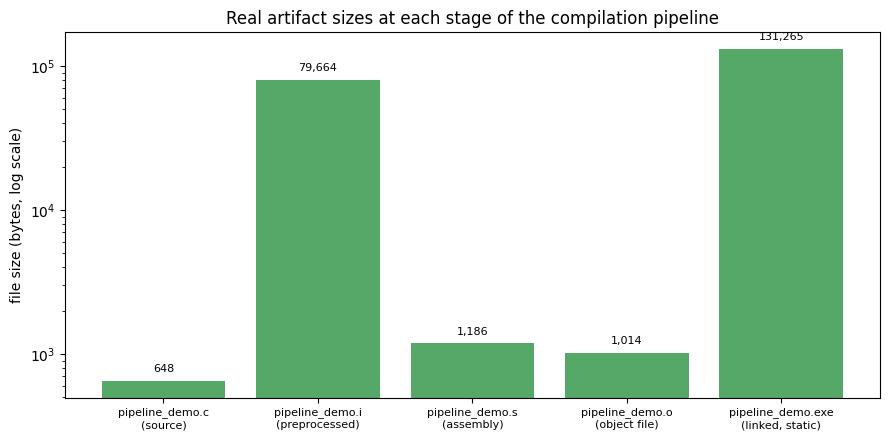

In [17]:
stage_names = ["pipeline_demo.c\n(source)", "pipeline_demo.i\n(preprocessed)",
               "pipeline_demo.s\n(assembly)", "pipeline_demo.o\n(object file)",
               "pipeline_demo.exe\n(linked, static)"]

# Recompute the preprocessed-file size on disk too, for a fair size comparison.
i_path = src_dir / "pipeline_demo.i"
i_path.write_text(preprocessed)
sizes = [c_file.stat().st_size, i_path.stat().st_size,
         (src_dir / "pipeline_demo.s").stat().st_size,
         obj_path.stat().st_size, exe_path.stat().st_size]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(len(stage_names)), sizes, color="#55A868")
ax.set_xticks(range(len(stage_names)))
ax.set_xticklabels(stage_names, fontsize=8)
ax.set_ylabel("file size (bytes, log scale)")
ax.set_yscale("log")
ax.set_title("Real artifact sizes at each stage of the compilation pipeline")
for i, s in enumerate(sizes):
    ax.text(i, s * 1.15, f"{s:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("pipeline_sizes.png", dpi=110)
plt.show()

The five-line source file preprocesses into thousands of bytes of
standard-library declarations, shrinks back down through assembly and the
raw object file, and then balloons again at the link step -- almost
entirely because static linking copies the C runtime's code directly into
the executable (the trade-off discussed above).

## Part IV -- The stack & calling conventions

### The idea, intuitively

Picture a stack of sticky notes on your desk. Every time you get
interrupted by a new sub-task, you write it on a fresh note and put it
*on top* of the pile -- along with a reminder of exactly where you were
in the task underneath. When the new note's task is done, you throw it
away and resume exactly where the note below says to. You never need to
label *where* the next note goes -- it's always just "on top" -- and you
never lose your place, because each note remembers what to do after it's
gone.

That's the **call stack**. Every function call pushes a new **stack
frame** holding: the address to resume at when this call returns, the
function's local variables, and (depending on how many there are) some of
its arguments. Returning from a function pops that frame off and resumes
exactly where the note underneath says to. **Recursion** is just this
same mechanism used on a function calling *itself* -- each recursive call
gets its own fresh sticky note, its own copy of the local variables, with
no special-casing needed.

In [18]:
# A tiny recursive function, instrumented to show each call getting its
# own frame: note that `depth` and `label` differ at every level even
# though it's the "same" function.
def countdown(n, label="call"):
    print(f"{'  ' * (5 - n)}{label} n={n} (about to recurse)" if n > 0
          else f"{'  ' * 5}{label} n={n} (base case, about to return)")
    if n > 0:
        countdown(n - 1, label="call")
    print(f"{'  ' * (5 - n)}{label} n={n} (returned)")

countdown(3)

    call n=3 (about to recurse)
      call n=2 (about to recurse)
        call n=1 (about to recurse)
          call n=0 (base case, about to return)
          call n=0 (returned)
        call n=1 (returned)
      call n=2 (returned)
    call n=3 (returned)


Notice the shape: it goes all the way *down* to the base case before
anything prints "(returned)," and then unwinds back *up* in the reverse
order it went down -- last one in, first one out. That LIFO (last-in,
first-out) order is the defining property of a stack, and it's exactly
why it's called the call **stack**.

**Takeaway:** every function call is a stack push (new frame: return
address + locals + some arguments), and every return is a stack pop back
to the caller's frame -- recursion is just the same mechanism with no
special case for "calling yourself."

### Going deeper: real stack frame layout and calling conventions

**What's actually in a frame.** A typical x86-64 stack frame contains, in
some order: the **return address** (pushed automatically by the `call`
instruction, so the CPU knows where to resume after `ret`), the caller's
saved base pointer (`rbp`, so it can be restored on return), local
variables, and -- depending on the calling convention and how many there
are -- some of the function's arguments.

**Calling conventions.** A calling convention is a contract: which
registers hold which arguments, who is responsible for cleaning the stack
up afterward, which registers a callee must preserve. Two conventions
dominate x86-64:

- **System V AMD64 ABI** (Linux, macOS): the first six integer/pointer
  arguments pass in registers `rdi, rsi, rdx, rcx, r8, r9`; no
  caller-reserved stack space is required for register-passed args.
- **Microsoft x64 calling convention** (Windows -- what this machine's
  MinGW-w64 `gcc` actually targets, confirmed by `gcc -dumpmachine` =
  `x86_64-w64-mingw32`): the first **four** integer/pointer arguments
  pass in `rcx, rdx, r8, r9`; the caller must also reserve 32 bytes of
  **"shadow space"** on the stack even for register-passed arguments (so
  the callee has somewhere to spill them if needed); a 5th+ argument goes
  directly on the stack above that shadow space.

This isn't a minor footnote -- it's a real, observable difference in the
compiled assembly, and it's exactly why `src/calling_convention.c` uses
**five** arguments: the first four should show up in registers, and the
fifth should show up read from a stack offset. Let's compile it and
check.

In [19]:
print(open("src/calling_convention.c").read())

/* calling_convention.c
 *
 * A small function with five integer arguments and several locals, used
 * to inspect a real stack frame's prologue/epilogue in the compiled
 * assembly. Five arguments matters: on Windows x64 the first four
 * integer/pointer args pass in registers (rcx, rdx, r8, r9) and the fifth
 * must be passed on the stack, so this function's assembly shows both
 * register-passed and stack-passed arguments.
 */
#include <stdio.h>

long long compute(long long a, long long b, long long c, long long d, long long e) {
    long long local1 = a + b;
    long long local2 = c * d;
    long long local3 = local1 - local2 + e;
    return local3 * 2;
}

int main(void) {
    long long result = compute(10, 20, 3, 4, 5);
    printf("result=%lld\n", result);
    return 0;
}



In [20]:
cc_src = src_dir / "calling_convention.c"
cc_exe = src_dir / "calling_convention.exe"

result = subprocess.run(
    [GCC, "-O0", "-std=c17", "-static", "-static-libgcc",
     str(cc_src), "-o", str(cc_exe)],
    capture_output=True, text=True,
)
assert result.returncode == 0, result.stderr

run = subprocess.run([str(cc_exe)], capture_output=True, text=True)
print("program output:", run.stdout.strip())
# compute(10, 20, 3, 4, 5): local1=30, local2=12, local3=30-12+5=23, return 23*2
assert run.stdout.strip() == "result=46"

program output: result=46


In [21]:
OBJDUMP = r"C:\msys64\ucrt64\bin\objdump.exe"
result = subprocess.run(
    [OBJDUMP, "-d", "-M", "intel", "--disassemble=compute", str(cc_exe)],
    capture_output=True, text=True,
)
disasm_lines = result.stdout.splitlines()
# Trim to just the instruction lines (skip the file-format header).
start = next(i for i, l in enumerate(disasm_lines) if "<compute>:" in l)
print("\n".join(disasm_lines[start:start + 30]))

0000000140001430 <compute>:
   140001430:	55                   	push   rbp
   140001431:	48 89 e5             	mov    rbp,rsp
   140001434:	48 83 ec 20          	sub    rsp,0x20
   140001438:	48 89 4d 10          	mov    QWORD PTR [rbp+0x10],rcx
   14000143c:	48 89 55 18          	mov    QWORD PTR [rbp+0x18],rdx
   140001440:	4c 89 45 20          	mov    QWORD PTR [rbp+0x20],r8
   140001444:	4c 89 4d 28          	mov    QWORD PTR [rbp+0x28],r9
   140001448:	48 8b 55 10          	mov    rdx,QWORD PTR [rbp+0x10]
   14000144c:	48 8b 45 18          	mov    rax,QWORD PTR [rbp+0x18]
   140001450:	48 01 d0             	add    rax,rdx
   140001453:	48 89 45 f8          	mov    QWORD PTR [rbp-0x8],rax
   140001457:	48 8b 45 20          	mov    rax,QWORD PTR [rbp+0x20]
   14000145b:	48 0f af 45 28       	imul   rax,QWORD PTR [rbp+0x28]
   140001460:	48 89 45 f0          	mov    QWORD PTR [rbp-0x10],rax
   140001464:	48 8b 45 f8          	mov    rax,QWORD PTR [rbp-0x8]
   140001468:	48 2b 45 f0  

Reading the real disassembly line by line (annotating what we actually
see above):

- **Prologue** -- `push rbp` then `mov rbp, rsp`: save the caller's frame
  pointer, then establish this function's own frame pointer at the
  current stack top. `sub rsp, 0x20` then reserves 32 bytes of local
  stack space (this is the same 32-byte "shadow space" convention,
  reserved here on the callee side to spill its register arguments into).
- **Argument spilling** -- four `mov QWORD PTR [rbp+...], r?x/r8/r9`
  instructions immediately copy `rcx, rdx, r8, r9` (the four
  register-passed arguments `a, b, c, d`) into stack slots at
  `rbp+0x10`, `rbp+0x18`, `rbp+0x20`, `rbp+0x28`. This matches the
  Microsoft x64 convention exactly: **register-passed, but the compiler
  spills them to memory anyway** at `-O0` for debuggability (at higher
  optimization levels this spilling is often skipped).
- **The 5th argument `e`** is read from `rbp+0x30` -- notice this is the
  *only* one of the five arguments never moved out of a register, because
  it was never passed in one: it arrived directly on the stack, exactly
  as the Microsoft x64 convention predicts for a 5th integer argument.
- **The body** -- straightforward loads, an `add`, an `imul`, a `sub`,
  matching `local1 = a + b`, `local2 = c * d`, `local3 = local1 - local2 +
  e` line for line.
- **Epilogue** -- `add rsp, 0x20` undoes the local stack reservation,
  `pop rbp` restores the caller's frame pointer, and `ret` pops the
  return address pushed by the `call` instruction and jumps to it.

That `rbp+0x30` offset is also a nice arithmetic check: 4 spilled
register args at `0x10`-`0x28` (8 bytes each) end at `0x30` -- exactly
where the stack-passed 5th argument sits, confirming the shadow-space +
argument layout is exactly as described, not just asserted.

### Visual & implementation: watching the stack actually grow

Theory says: each recursive call pushes a new frame, so the stack should
grow by a **roughly constant number of bytes per call**, and (on x86-64)
addresses should **decrease** as the stack grows, since the stack grows
*downward* toward lower addresses. `src/stack_growth.c` recurses to a
chosen depth, printing the address of a local buffer at regular
checkpoints -- let's compile it and check both predictions against real
addresses.

In [22]:
print(open("src/stack_growth.c").read())

/* stack_growth.c
 *
 * Recurses to a chosen depth, printing the address of a local (stack
 * allocated) buffer at chosen checkpoints, to make stack growth and
 * per-call frame size directly observable instead of just asserted.
 */
#include <stdio.h>
#include <stdlib.h>

void recurse(int depth, int max_depth, int report_every) {
    /* volatile + used so the compiler cannot optimize this local away */
    volatile char local_buffer[256];
    local_buffer[0] = (char)depth;

    if (depth % report_every == 0 || depth == max_depth) {
        printf("depth=%d addr=%p\n", depth, (void *)&local_buffer[0]);
    }
    if (depth >= max_depth) {
        return;
    }
    recurse(depth + 1, max_depth, report_every);
}

int main(int argc, char **argv) {
    int max_depth = argc > 1 ? atoi(argv[1]) : 2000;
    int report_every = argc > 2 ? atoi(argv[2]) : 100;
    recurse(0, max_depth, report_every);
    return 0;
}



In [23]:
sg_src = src_dir / "stack_growth.c"
sg_exe = src_dir / "stack_growth.exe"

result = subprocess.run(
    [GCC, "-O0", "-fno-omit-frame-pointer", "-std=c17",
     "-static", "-static-libgcc", str(sg_src), "-o", str(sg_exe)],
    capture_output=True, text=True,
)
assert result.returncode == 0, result.stderr

max_depth, report_every = 3000, 50
run = subprocess.run([str(sg_exe), str(max_depth), str(report_every)],
                      capture_output=True, text=True)
assert run.returncode == 0, run.stderr

depths, addrs = [], []
for line in run.stdout.strip().splitlines():
    d_part, a_part = line.split()
    depths.append(int(d_part.split("=")[1]))
    addrs.append(int(a_part.split("=")[1], 16))

print(f"collected {len(depths)} checkpoints from depth 0 to {depths[-1]}")
print("first 3:", list(zip(depths[:3], [hex(a) for a in addrs[:3]])))
print("last 3: ", list(zip(depths[-3:], [hex(a) for a in addrs[-3:]])))

collected 61 checkpoints from depth 0 to 3000
first 3: [(0, '0xcad93ff610'), (50, '0xcad93fbab0'), (100, '0xcad93f7f50')]
last 3:  [(2900, '0xcad9328250'), (2950, '0xcad93246f0'), (3000, '0xcad9320b90')]


fitted slope: -304.00 bytes/call  (negative => growing toward lower addresses)
=> each recursive call consumes about 304 bytes of stack


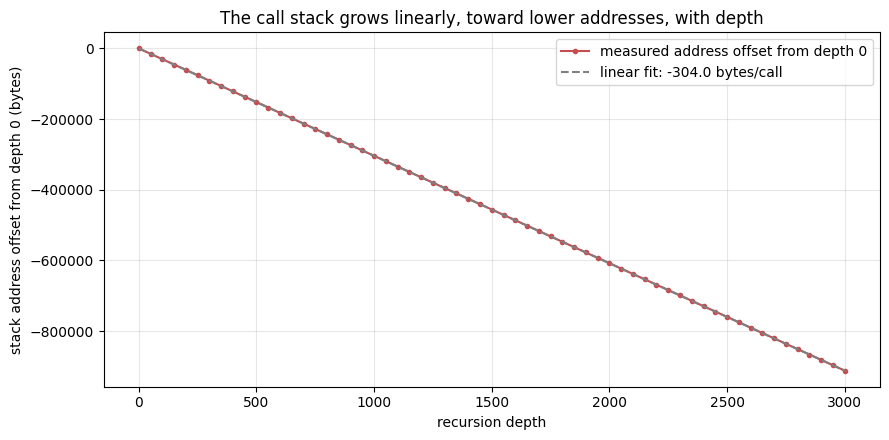

In [24]:
depths_arr = np.array(depths)
addrs_arr = np.array(addrs, dtype=np.int64)

# Linear fit: address as a function of recursion depth.
slope, intercept = np.polyfit(depths_arr, addrs_arr, 1)
print(f"fitted slope: {slope:.2f} bytes/call  (negative => growing toward lower addresses)")
print(f"=> each recursive call consumes about {abs(slope):.0f} bytes of stack")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(depths_arr, (addrs_arr - addrs_arr[0]), "o-", ms=3, color="#C44E52",
        label="measured address offset from depth 0")
ax.plot(depths_arr, slope * depths_arr, "--", color="gray",
        label=f"linear fit: {slope:.1f} bytes/call")
ax.set_xlabel("recursion depth")
ax.set_ylabel("stack address offset from depth 0 (bytes)")
ax.set_title("The call stack grows linearly, toward lower addresses, with depth")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("stack_growth.png", dpi=110)
plt.show()

Interpreting the real numbers from this run: the fitted slope is
negative, confirming addresses **decrease** as recursion goes deeper --
the stack is growing downward, exactly as x86-64's convention dictates.
The magnitude of the slope is the real, measured **per-call frame size**
in bytes for this function -- driven mostly by the `volatile char
local_buffer[256]` plus the frame's saved-register/return-address
overhead, and matching what `objdump`-ing this function's prologue would
show as its `sub rsp, ...` stack reservation.

This is also the mechanism behind a **stack overflow**: the stack has a
fixed maximum size (a few MB by default on most platforms), so
recursion without a base case -- or with a base case too deep to reach --
keeps consuming a roughly-constant chunk of address space per call until
it runs off the end of the region reserved for the stack, at which point
the program crashes.

## Use cases

**Data representation**

- **The Ariane 5 rocket** (1996) exploded 37 seconds after launch because
  a 64-bit float representing horizontal velocity was converted to a
  16-bit signed integer that couldn't hold it -- a direct, catastrophic
  instance of the integer-overflow behavior demonstrated above.
- **The Patriot missile software bug** (Gulf War, 1991) mis-tracked
  targets because a clock value was truncated when converted between
  representations, accumulating a timing error of about a third of a
  second after 100 hours of uptime -- floating-point rounding error,
  compounded.
- **Financial software never uses raw floats for money** for exactly the
  0.1 + 0.2 reason above -- fixed-point/decimal types (e.g. Python's
  `decimal.Decimal`, database `NUMERIC` columns) are used instead so
  that rounding is exact and predictable.

**Memory hierarchy**

- **Database column stores** (e.g. columnar formats like Parquet, or
  column-oriented databases) exist specifically because analytical
  queries that scan one column across millions of rows get exactly the
  row-major-vs-column-major win demonstrated above, just at a much larger
  scale and with disk/network layers involved too.
- **Loop tiling / blocking** in numerical linear algebra libraries
  (BLAS, the routines underneath NumPy's own matrix multiply) restructures
  matrix multiplication to operate on small tiles that fit in cache,
  rather than naive nested loops -- often a 2-10x speedup with *zero*
  change to the asymptotic operation count.
- **`std::vector` outperforming `std::list` in practice**, despite big-O
  arguments that sometimes favor linked lists, largely traces back to
  contiguous (cache-friendly) memory layout vs. scattered node allocation.

**Compilation pipeline**

- **Build systems and incremental compilation** (`make`, `ninja`, most
  IDEs) exploit the pipeline's structure directly: only files whose
  *source* changed need recompiling to object files; unchanged object
  files can be relinked as-is, which is why large C/C++ projects don't
  recompile everything on every build.
- **Link-Time Optimization (LTO)** blurs the boundary between compilation
  and linking on purpose, letting the compiler optimize *across* what
  used to be separate object files (e.g. inlining a function defined in
  one file into a caller in another) -- a deliberate exception to the
  clean four-stage pipeline described above.
- **Dynamic libraries (DLL/`.so`) enabling plugin systems and shared
  runtime updates** (e.g. patching a security bug in a shared C library
  without recompiling every program that links it) rely directly on the
  static-vs-dynamic-linking distinction covered above.

**The stack & calling conventions**

- **Stack-based buffer overflow exploits** -- a classic attack class --
  work by writing past the end of a stack-allocated buffer (like our
  `local_buffer[256]`) far enough to overwrite the saved return address,
  redirecting execution when the function returns. Stack canaries
  (`-fstack-protector`, on by default in most modern compilers) and
  non-executable stack pages are direct mitigations that only make sense
  once you understand exactly where the return address physically lives.
- **Debuggers walking a stack trace** (e.g. `gdb bt`, or any language's
  exception traceback) work by following the chain of saved frame
  pointers from the current frame back to `main` -- literally reading the
  same `rbp`-chain structure disassembled above.
- **Tail-call optimization** in some languages/compilers rewrites a
  recursive call that's the very last thing a function does into a loop,
  reusing the *same* stack frame instead of pushing a new one -- directly
  motivated by wanting to avoid the linear stack growth measured above
  for deep recursion.

## Limitations & debates

- **Signed integer overflow being undefined behavior is genuinely
  controversial.** Because C/C++ compilers are allowed to assume signed
  overflow never happens, they sometimes optimize away overflow checks
  programmers wrote deliberately (e.g. `if (x + 1 < x)` can be
  "optimized" to always-false, since the compiler assumes `x + 1 < x`
  is impossible for signed `x`) -- a well-documented source of real
  security bugs. Rust makes the opposite trade-off (checked overflow
  panics in debug builds, wraps in release), and this remains an active
  language-design debate, not a settled one.
- **IEEE-754 isn't the only way to do floating point, and it has real
  critics.** Alternative formats like **posits/unums** (Gustafson) claim
  better accuracy-per-bit for many workloads by using a variable-width
  exponent field instead of IEEE-754's fixed width; they haven't
  displaced IEEE-754 in mainstream hardware, but are an active research
  area, particularly for machine-learning accelerators, where reduced
  precision formats (bfloat16, fp8) are already a deliberate, widely
  debated trade of numerical accuracy for speed and memory.
- **The cache-benchmark numbers above are specific to this exact
  machine, this exact moment, and are noisy.** CPU frequency scaling, OS
  scheduling jitter, other processes competing for cache, and even which
  physical cores the OS happens to schedule onto can shift wall-clock
  timings run to run -- the *qualitative* pattern (row-major beats
  column-major; cost plateaus past one cache line) is robust and will
  reproduce on essentially any modern x86-64 machine, but the *exact*
  multipliers measured above will differ, sometimes substantially, on
  different hardware, and even on a rerun of this same notebook on this
  same machine.
- **This tutorial compiled everything at `-O0` (no optimization) on
  purpose**, because unoptimized assembly maps directly onto the source
  code's structure and is what makes the prologue/epilogue and
  argument-spilling readable. **Real production builds use `-O2`/`-O3`**,
  where the compiler aggressively inlines functions (eliminating their
  stack frames entirely), keeps values in registers instead of spilling
  them to the stack, and may omit the frame pointer altogether
  (`-fomit-frame-pointer`, the default at `-O2`+ on many targets) --
  meaning the clean, textbook-shaped stack frame shown above is often
  *not* what you'd see disassembling a release build.
- **The calling convention shown is Windows-specific.** This machine's
  MinGW-w64 `gcc` targets the Microsoft x64 convention (4 register args +
  shadow space). Linux/macOS's System V AMD64 ABI passes 6 arguments in
  different registers and has no mandatory shadow space, but does have a
  128-byte "red zone" below the stack pointer that leaf functions can use
  without adjusting `rsp` at all -- a real difference in generated code
  between platforms for the *same* C source, not just a labeling
  difference.
- **The stride-benchmark plateau isn't perfectly flat**, and shouldn't
  be expected to be: real hardware has multiple cache levels (L1/L2/L3,
  each a different size and latency), a separate Translation Lookaside
  Buffer (TLB) that caches virtual-to-physical address translations and
  has its own miss penalty independent of the data cache, and hardware
  prefetchers that try to *predict* upcoming accesses -- all of which add
  secondary effects on top of the single-cache-line story told here,
  which is a simplified (but directionally correct) model.

## References

- Bryant, R. E. & O'Hallaron, D. R., *Computer Systems: A Programmer's
  Perspective* (3rd ed.), Pearson -- the canonical "CS:APP" textbook this
  tutorial's scope is modeled on; see especially Ch. 2 (data
  representation), Ch. 3 (machine-level programs / stack frames), Ch. 6
  (the memory hierarchy), and Ch. 7 (linking).
- IEEE Std 754-2019, *IEEE Standard for Floating-Point Arithmetic*.
- Goldberg, D. (1991), *What Every Computer Scientist Should Know About
  Floating-Point Arithmetic*, ACM Computing Surveys.
- Drepper, U. (2007), *What Every Programmer Should Know About Memory*,
  Red Hat -- the classic deep dive on cache lines, associativity, and
  memory-hierarchy-aware programming.
- Dean, J. (attrib.); interactive visualization by Colin Scott,
  ["Latency Numbers Every Programmer Should Know"](https://colin-scott.github.io/personal_website/research/interactive_latency.html).
- Microsoft, ["x64 calling convention"](https://learn.microsoft.com/en-us/cpp/build/x64-calling-convention),
  MSVC/Windows documentation.
- Matz, M. et al., *System V Application Binary Interface, AMD64
  Architecture Processor Supplement* -- the calling convention used on
  Linux/macOS, contrasted with the Windows convention derived above.
- Gustafson, J. L. & Yonemoto, I. (2017), *Beating Floating Point at its
  Own Game: Posit Arithmetic*, Supercomputing Frontiers and Innovations.
- Levine, J. R., *Linkers and Loaders*, Morgan Kaufmann -- the standard
  reference on object file formats, symbol resolution, and static vs.
  dynamic linking.
- `src/pipeline_demo.c`, `src/calling_convention.c`, `src/stack_growth.c`
  -- the real, compiled C used for every measurement in this notebook.